In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
file = "/home/zhe2/data/MyProjects/PACE_redSIF_PACE/morel_fq_hyperspectral.nc"
ds = xr.open_dataset(file, engine="netcdf4")

wave = ds.wave.values
solz = ds.solz.values
phi  = ds.phi.values  # relative azimuth angle
tau  = ds.tau.values  # aerosol optical thickness
senz = ds.senz.values
chl  = ds.chl.values

foq  = ds.foq
foq_tau = ds.foq_tau

In [4]:
ds

<xarray.Dataset> Size: 4MB
Dimensions:  (wave: 70, solz: 6, chl: 6, senz: 10, phi: 7, tau: 5)
Coordinates:
  * wave     (wave) float32 280B 352.5 357.5 362.5 367.5 ... 687.5 692.5 697.5
  * solz     (solz) float32 24B 0.0 15.0 30.0 45.0 60.0 75.0
  * chl      (chl) float32 24B 0.03 0.1 0.3 1.0 3.0 10.0
  * senz     (senz) float32 40B 0.0 2.194 6.937 12.79 ... 37.35 43.54 49.73
  * phi      (phi) float32 28B 0.0 30.0 60.0 90.0 120.0 150.0 180.0
  * tau      (tau) float32 20B 0.05 0.1 0.2 0.4 1.0
Data variables:
    foq      (wave, solz, chl, senz, phi) float32 706kB ...
    foq_tau  (wave, solz, tau, chl, senz, phi) float32 4MB ...
Attributes: (12/13)
    title:            Hyperspectral BRDF foq tables
    Conventions:      CF-1.8
    project:          Ocean Biology Processing Group (NASA/GSFC/OBPG)
    institution:      NASA Goddard Space Flight Center, Ocean Ecology Laborat...
    date_created:     2026-02-09T20:35:39.119Z
    foq_tau_for_c:    0.20000000298023224
    ...               ...
    creator_name:     NASA/GSFC/OBPG
    publisher_name:   NASA/GSFC/OBPG
    creator_email:    data@oceancolor.gsfc.nasa.gov
    publisher_email:  data@oceancolor.gsfc.nasa.gov
    creator_url:      https://oceandata.sci.gsfc.nasa.gov
    publisher_url:    https://oceandata.sci.gsfc.nasa.gov

In [9]:
# print variables
print("sza: ", solz)
print("tau: ", tau)
print("chl: ", chl)
print("senz: ", senz)
print("phi: ", phi)



sza:  [ 0. 15. 30. 45. 60. 75.]
tau:  [0.05 0.1  0.2  0.4  1.  ]
chl:  [ 0.03  0.1   0.3   1.    3.   10.  ]
senz:  [ 0.      2.1943  6.9368 12.7899 18.8685 25.0086 31.1739 37.3518 43.5369
 49.7265]
phi:  [  0.  30.  60.  90. 120. 150. 180.]


#### Spectra

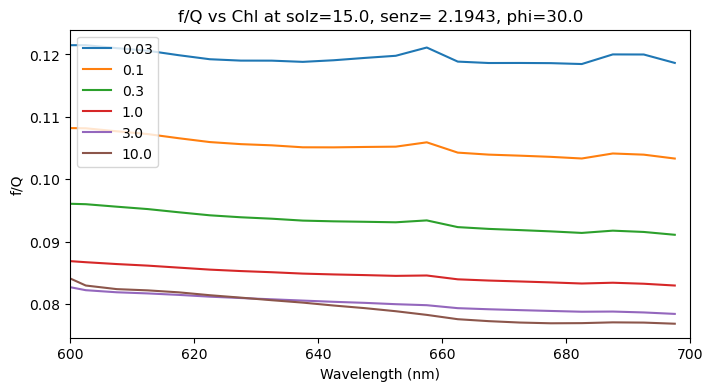

In [21]:
solz_ind = 1
senz_ind = 1
phi_ind = 1
foq_vs_chl = foq.values[:, solz_ind, :, senz_ind, phi_ind]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(wave, foq_vs_chl, label=chl)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("f/Q")
ax.set_title(f"f/Q vs Chl at solz={solz[solz_ind]}, senz={senz[senz_ind]: .4f}, phi={phi[phi_ind]}")
ax.set_xlim(600, 700)
ax.legend(loc="upper left")

TypeError: Dimensions of C (70, 6) should be one smaller than X(70) and Y(6) while using shading='flat' see help(pcolormesh)

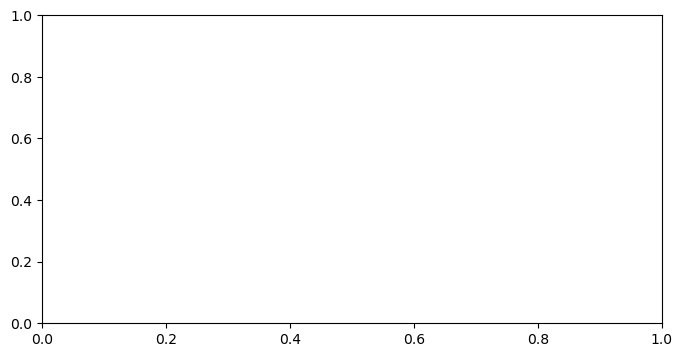

In [22]:
# pcolormesh wave vs. chl
fig, ax = plt.subplots(figsize=(8, 4))
ax.pcolormesh(wave, chl, foq.values[:, solz_ind, :, senz_ind, phi_ind], cmap='viridis')
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Chl")
ax.set_title(f"f/Q vs Chl at solz={solz[solz_ind]}, senz={senz[senz_ind]: .4f}, phi={phi[phi_ind]}")
ax.set_xlim(600, 700)
ax.legend(loc="upper left")

#### Designated wavelength?


In [5]:
# select single wavelength
wave_idx = -4
target_wave = wave[wave_idx]
print(f"target_wave: {target_wave} nm")


target_wave: 682.5 nm


Text(0.5, 1.0, 'f/Q (fraction of photons?) @ 682.5 nm')

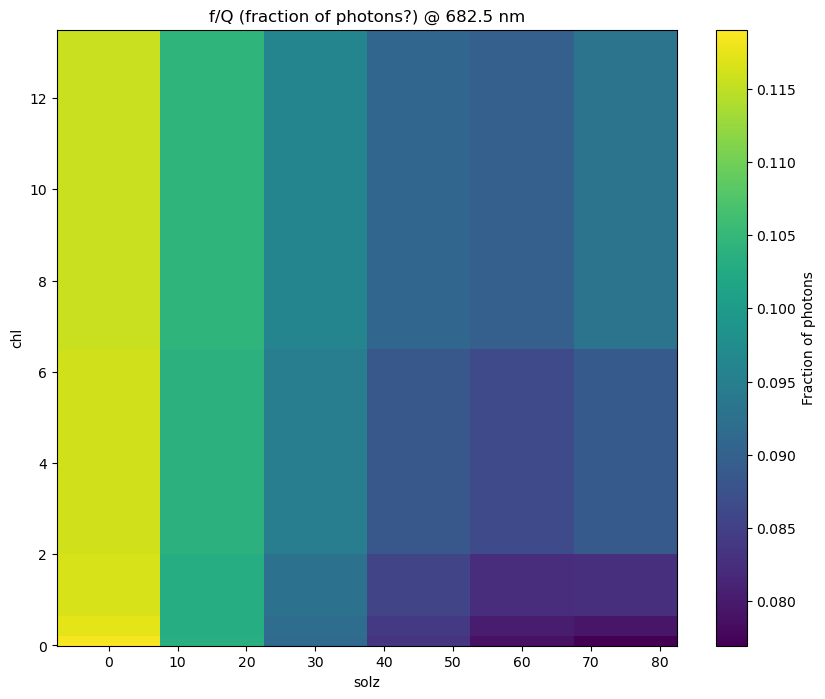

In [6]:
# heatmap of foq
plt.figure(figsize=(10, 8))
plt.pcolormesh(solz, chl, foq.values[wave_idx, :, :, 0, 0], cmap='viridis')
plt.colorbar(label='Fraction of photons')
plt.xlabel('solz')
plt.ylabel('chl')
plt.title(f'f/Q (fraction of photons?) @ {target_wave} nm')